In [1]:
import pandas as pd

In [2]:
df= pd.read_csv("C:\\Users\\User\\Desktop\\python\\svm_cats_dogs_overlap.csv")
df

,Height_cm,Weight_kg,Animal,Tail_Length_cm
0,39.92,8.56,Dog,25.50
1,40.05,13.48,Dog,29.35
2,40.87,6.31,Dog,19.51
3,43.77,10.12,Dog,39.59
4,30.92,11.60,Dog,26.08
...,...,...,...,...
395,31.73,5.77,Cat,15.77
396,24.04,4.39,Cat,40.04
397,20.43,4.78,Cat,31.51
398,24.85,8.63,Dog,28.99


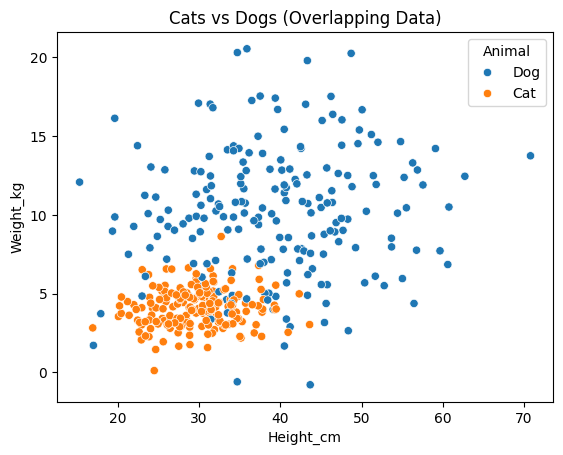

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.scatterplot(data=df, x="Height_cm", y="Weight_kg", hue="Animal")
plt.title("Cats vs Dogs (Overlapping Data)")
plt.show()

In [8]:
df=df[["Height_cm","Weight_kg","Animal"]]
df

,Height_cm,Weight_kg,Animal
0,39.92,8.56,Dog
1,40.05,13.48,Dog
2,40.87,6.31,Dog
3,43.77,10.12,Dog
4,30.92,11.60,Dog
...,...,...,...
395,31.73,5.77,Cat
396,24.04,4.39,Cat
397,20.43,4.78,Cat
398,24.85,8.63,Dog


In [9]:
X = df[["Height_cm","Weight_kg"]]
y = df['Animal']

In [10]:
from sklearn.preprocessing import LabelEncoder
LE = LabelEncoder()
y = LE.fit_transform(y)
y

array([1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1,
       1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1,
       1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0,

In [11]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()

X = ss.fit_transform(X)
X = pd.DataFrame(X,columns=["H","W"])
X

,H,W
0,0.602669,0.353543
1,0.617045,1.520633
2,0.707719,-0.180187
3,1.028398,0.723596
4,-0.392542,1.074672
...,...,...
395,-0.302973,-0.308283
396,-1.153325,-0.635637
397,-1.552515,-0.543124
398,-1.063756,0.370148


In [12]:
from sklearn.model_selection import  train_test_split 

In [13]:
X_test , X_train ,y_test , y_train = train_test_split(X,y)

In [14]:
from sklearn.svm import SVC
model = SVC()
model.fit(X_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
